In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from pathlib import Path

from PIL import Image
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torchvision.models import ConvNeXt_Base_Weights, convnext_base
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split

DATA_DIR = Path("dataset")
IMAGE_DIR = DATA_DIR / "images"
TRAIN_CSV = DATA_DIR / "train.csv"
TEST_CSV = DATA_DIR / "test.csv"
BATCH_SIZE = 16
NUM_EPOCHS = 15

train_df = pd.read_csv(TRAIN_CSV)
classes = sorted(train_df["label"].unique())
class_to_idx = {label: idx for idx, label in enumerate(classes)}
idx_to_class = {idx: label for label, idx in class_to_idx.items()}
num_classes = len(classes)

class ChessDataset(Dataset):
    def __init__(self, csv_path, transform=None, class_to_idx=None, has_labels=True):
        self.data = pd.read_csv(csv_path)
        self.transform = transform
        self.class_to_idx = class_to_idx or {}
        self.has_labels = has_labels and "label" in self.data.columns

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]
        image_path = IMAGE_DIR / row["image_path"]

        with Image.open(image_path) as img:
            image = img.convert("RGB")

        if self.transform:
            image = self.transform(image)

        if not self.has_labels:
            return image, row["id"]

        label = self.class_to_idx[row["label"]]
        return image, torch.tensor(label, dtype=torch.long)

train_transform = transforms.Compose([
      transforms.Resize(256),
      transforms.RandomCrop(224, padding=16),
      transforms.RandomRotation(10),
      #transforms.RandomGrayscale(p=0.5),
      transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225]),
  ])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

train_data = pd.read_csv(TRAIN_CSV)
indices = np.arange(len(train_data))
labels = train_data["label"].values
train_indices, eval_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=labels,
)

train_dataset = Subset(ChessDataset(TRAIN_CSV, train_transform, class_to_idx=class_to_idx), train_indices)
eval_dataset = Subset(ChessDataset(TRAIN_CSV, eval_transform, class_to_idx=class_to_idx), eval_indices)
test_dataset = ChessDataset(TEST_CSV, eval_transform, has_labels=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

eval_loader = DataLoader(
    eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)
print(classes)

def train(model, loader, criterion, optimizer):
    model.train()

    epoch_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        preds = logits.argmax(dim=1)

        correct += (preds == y).sum().item()
        total += y.size(0)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(y.detach().cpu().numpy())

    acc = correct / total
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return epoch_loss / len(loader), acc, f1

def evaluate(model, loader, criterion):
    model.eval()

    epoch_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            epoch_loss += loss.item()

            preds = logits.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(y.detach().cpu().numpy())

    acc = correct / total
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return epoch_loss / len(loader), acc, f1

def predict(model, loader):
    model.eval()
    rows = []

    with torch.no_grad():
        for x, ids in loader:
            x = x.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1).cpu().numpy()

            for sample_id, pred in zip(ids, preds):
                rows.append({"id": sample_id, "label": idx_to_class[int(pred)]})

    return pd.DataFrame(rows)

try:
    weights = ConvNeXt_Base_Weights.DEFAULT
    model = convnext_base(weights=weights)
except Exception as exc:
    print(f"Could not load pretrained ConvNeXt weights: {exc}")
    print("Training will be much weaker because the frozen backbone starts from random weights.")
    model = convnext_base(weights=None)

for param in model.parameters():
    param.requires_grad = False

# Fine-tune the last ConvNeXt block plus the classifier. Setting requires_grad on
# the module itself is not enough; it must be set on each parameter.
for param in model.features[-1][-1].parameters():
    param.requires_grad = True

in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, num_classes)
for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    [param for param in model.parameters() if param.requires_grad],
    lr=1e-4,
)

train_losses, eval_losses = [], []
train_accs, eval_accs = [], []
train_f1s, eval_f1s = [], []

for epoch in range(NUM_EPOCHS):
    tr_loss, tr_acc, tr_f1 = train(model, train_loader, criterion, optimizer)
    eval_loss, eval_acc, eval_f1 = evaluate(model, eval_loader, criterion)

    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    train_f1s.append(tr_f1)

    eval_losses.append(eval_loss)
    eval_accs.append(eval_acc)
    eval_f1s.append(eval_f1)

    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {tr_loss:.4f}   Train Acc: {tr_acc * 100:.2f}%   Train F1: {tr_f1:.4f}")
    print(f"  Eval  Loss: {eval_loss:.4f}   Eval  Acc: {eval_acc * 100:.2f}%   Eval  F1: {eval_f1:.4f}")

submission = predict(model, test_loader)
submission.to_csv("output.csv", index=False)
submission.head()


mps
['bishop', 'knight', 'pawn', 'queen', 'rook']
Epoch 1/15
  Train Loss: 1.5781   Train Acc: 26.20%   Train F1: 0.2399
  Eval  Loss: 1.4848   Eval  Acc: 48.08%   Eval  F1: 0.3667
Epoch 2/15
  Train Loss: 1.4457   Train Acc: 45.91%   Train F1: 0.3645
  Eval  Loss: 1.3535   Eval  Acc: 59.62%   Eval  F1: 0.4845
Epoch 3/15
  Train Loss: 1.3145   Train Acc: 51.68%   Train F1: 0.4287
  Eval  Loss: 1.1825   Eval  Acc: 69.23%   Eval  F1: 0.5856
Epoch 4/15
  Train Loss: 1.1955   Train Acc: 59.62%   Train F1: 0.5189
  Eval  Loss: 1.0158   Eval  Acc: 76.92%   Eval  F1: 0.7252
Epoch 5/15
  Train Loss: 1.0742   Train Acc: 67.07%   Train F1: 0.6053
  Eval  Loss: 0.8866   Eval  Acc: 76.92%   Eval  F1: 0.7260
Epoch 6/15
  Train Loss: 0.9816   Train Acc: 70.91%   Train F1: 0.6644
  Eval  Loss: 0.7611   Eval  Acc: 82.69%   Eval  F1: 0.8012
Epoch 7/15
  Train Loss: 0.9487   Train Acc: 69.95%   Train F1: 0.6578
  Eval  Loss: 0.6843   Eval  Acc: 83.65%   Eval  F1: 0.8116
Epoch 8/15
  Train Loss: 0.8576  

,id,label
0,P00521,knight
1,P00522,rook
2,P00523,queen
3,P00524,rook
4,P00525,bishop


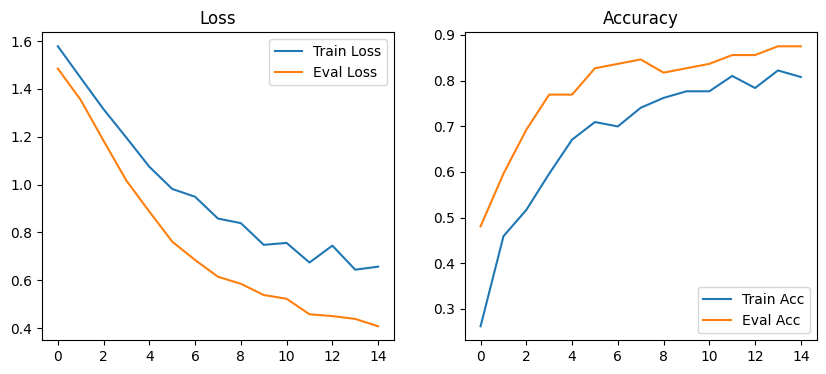

In [3]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(eval_losses, label="Eval Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(eval_accs, label="Eval Acc")
plt.legend()
plt.title("Accuracy")

plt.show()